In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

In [40]:
# ===== LOAD & CHUẨN BỊ =====
X, y_true = make_moons(n_samples=300, noise=0.08, random_state=42)
X = StandardScaler().fit_transform(X)

In [41]:
# ===== SPECTRAL CLUSTERING =====
spectral = SpectralClustering(n_clusters=2, affinity='rbf', gamma=1.0, random_state=42)
labels_spectral = spectral.fit_predict(X)
score_spectral = silhouette_score(X, labels_spectral)

# ===== K-MEANS (so sánh) =====
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X)
score_kmeans = silhouette_score(X, labels_kmeans)

In [42]:
print(f"  K-Means:      {score_kmeans:.4f} (tốt hơn 0.001)")
print(f"  Spectral:     {score_spectral:.4f}")

  K-Means:      0.4936 (tốt hơn 0.001)
  Spectral:     0.4924


In [43]:
silhouette_vals = silhouette_samples(X, labels_spectral)

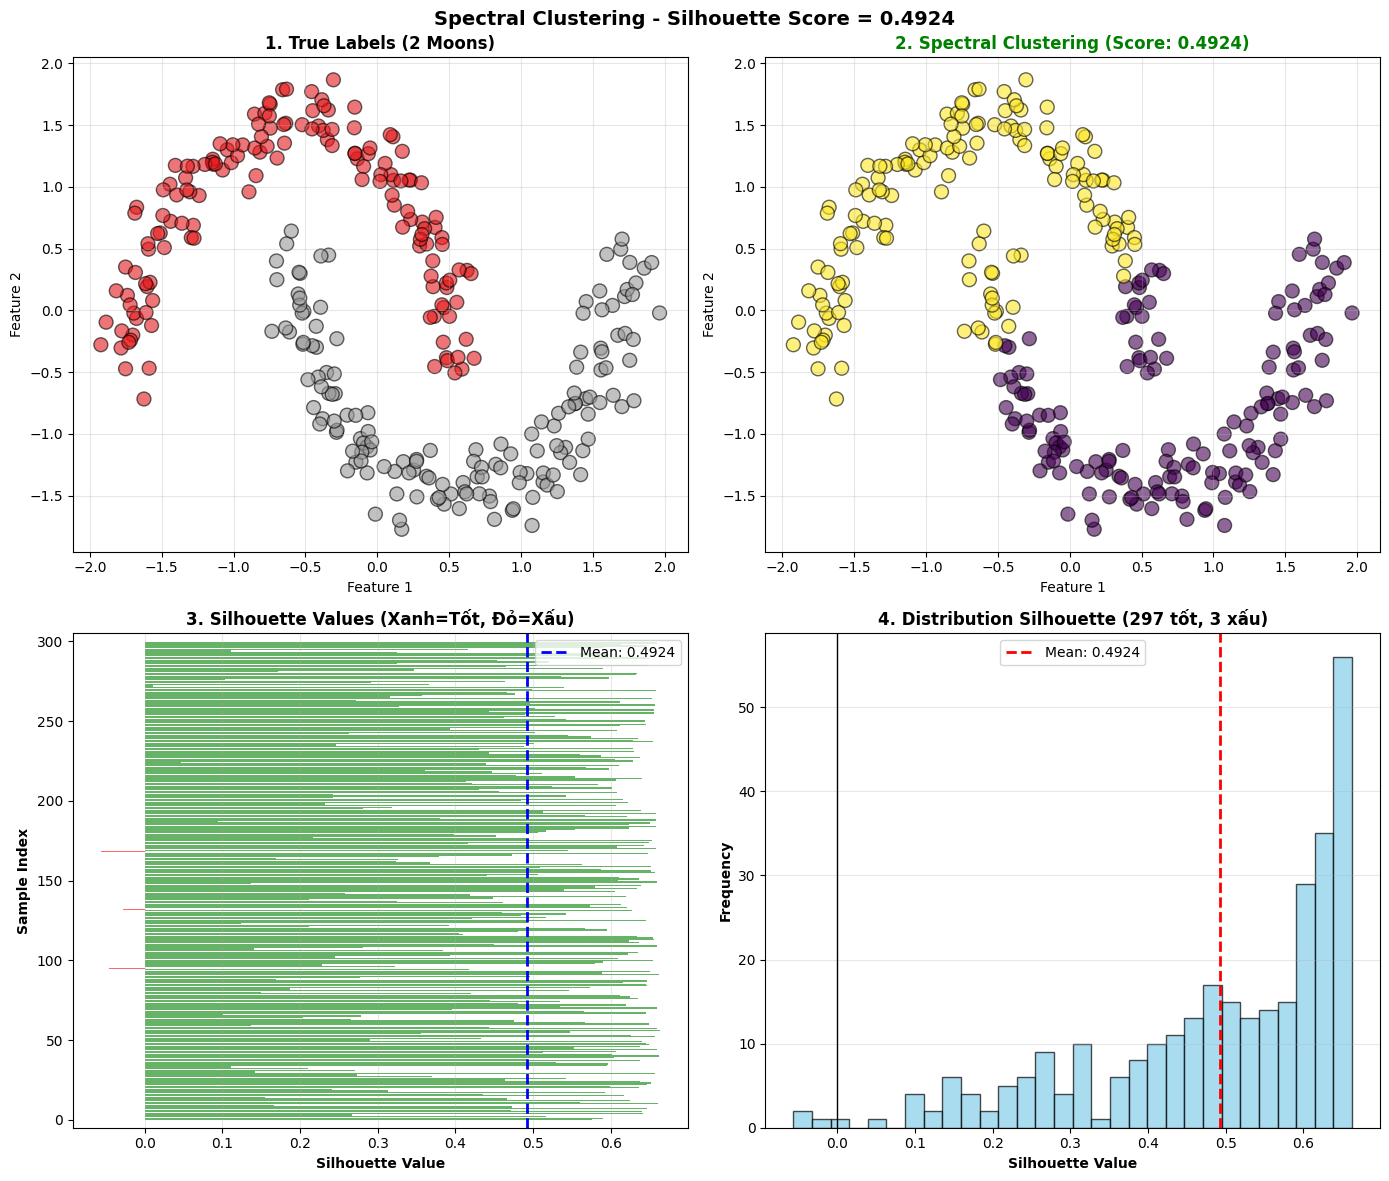

In [44]:

# ===== VẼ HÌNH =====
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Spectral Clustering - Silhouette Score = 0.4924', fontsize=14, fontweight='bold')

# 1. True Labels
ax1 = axes[0, 0]
scatter1 = ax1.scatter(X[:, 0], X[:, 1], c=y_true, cmap='Set1', s=100, alpha=0.6, edgecolors='k')
ax1.set_title('1. True Labels (2 Moons)', fontweight='bold')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.grid(alpha=0.3)

# 2. Spectral Clustering
ax2 = axes[0, 1]
scatter2 = ax2.scatter(X[:, 0], X[:, 1], c=labels_spectral, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
ax2.set_title(f'2. Spectral Clustering (Score: {score_spectral:.4f})', fontweight='bold', color='green')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.grid(alpha=0.3)

# 3. Silhouette per sample
ax3 = axes[1, 0]
colors = ['green' if x > 0 else 'red' for x in silhouette_vals]
ax3.barh(range(len(silhouette_vals)), silhouette_vals, color=colors, alpha=0.6, height=0.8)
ax3.axvline(score_spectral, color='blue', linestyle='--', linewidth=2, label=f'Mean: {score_spectral:.4f}')
ax3.set_xlabel('Silhouette Value', fontweight='bold')
ax3.set_ylabel('Sample Index', fontweight='bold')
ax3.set_title('3. Silhouette Values (Xanh=Tốt, Đỏ=Xấu)', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3, axis='x')
ax3.set_ylim(-5, 305)

# 4. Silhouette histogram
ax4 = axes[1, 1]
ax4.hist(silhouette_vals, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax4.axvline(score_spectral, color='red', linestyle='--', linewidth=2, label=f'Mean: {score_spectral:.4f}')
ax4.axvline(0, color='black', linestyle='-', linewidth=1)
ax4.set_xlabel('Silhouette Value', fontweight='bold')
ax4.set_ylabel('Frequency', fontweight='bold')
ax4.set_title(f'4. Distribution Silhouette ({np.sum(silhouette_vals > 0)} tốt, {np.sum(silhouette_vals <= 0)} xấu)', fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()